# AutoPulse：汽车销量预测与用户舆情分析

## 数据分析笔记本

本 Notebook 完整记录项目已完成的各阶段工作，展示每一步的实际操作与成果。当前已覆盖：

- **阶段一 · 数据准备**：多源数据采集 → 清洗 → 跨平台 ID 对齐 → 生成分析就绪表
- **阶段二 · 数据筛选与探索性可视化**：连续月份筛选、时序汇总、销量/分类/硬件可视化

- **阶段三 · 销量预测建模**：分层抽样评估、ARIMA / Prophet / Prophet+外生 / XGBoost / LSTM / 融合多模型对比、滚动验证、特征消融、预测区间

- **阶段四 · 舆情深度分析与销量归因**：深层 ABSA（全量 28,724 条评论）、XGBoost+SHAP 销量归因、Granger 时序因果

看板交付（交互式可视化）作为独立交付物并行推进。

## 1. 环境与路径

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

BASE = os.path.abspath('..')  # notebook folder is inside AutoPulse
RAW = os.path.join(BASE, 'data', 'raw')
SENTIMENT = os.path.join(BASE, 'data', 'sentiment')
PROC = os.path.join(BASE, 'data', 'processed')
PROC3 = os.path.join(BASE, 'data', 'processed', 'stage3')   # stage-3 model artifacts
FIG = os.path.join(BASE, 'figures')

for d in [PROC, PROC3, FIG]:
    os.makedirs(d, exist_ok=True)

print('Project root:', BASE)
print('Raw data dir:', RAW)
print('Sentiment dir:', SENTIMENT)

Project root: /Users/ye/dev/projects/AutoPulse
Raw data dir: /Users/ye/dev/projects/AutoPulse/data/raw
Sentiment dir: /Users/ye/dev/projects/AutoPulse/data/sentiment


### 图表样式（英文标签，简洁浅色风格）

In [2]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': [
        'PingFang SC', 'Heiti SC', 'Hiragino Sans GB',
        'SimHei', 'Noto Sans CJK SC', 'Microsoft YaHei',
        'DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif'
    ],
    'axes.unicode_minus': False,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#333333',
    'text.color': '#333333',
    'xtick.color': '#555555',
    'ytick.color': '#555555',
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'savefig.facecolor': 'white',
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '-',
    'grid.linewidth': 0.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

COLORS = {
    'blue': '#2E86AB', 'orange': '#F18F01', 'green': '#3E8914',
    'red': '#C73E1D', 'purple': '#6A4C93', 'teal': '#1B998B', 'gray': '#8D99AE'
}

## 2. 阶段一：数据准备

阶段一是整个项目的数据地基，共完成 **6 份数据集**的采集、清洗与对齐。所有原始数据体积较大且不入库（可由 `scripts/` 下脚本完整复现），本节展示其结构、质量与核心成果。

### 2.1 一次性加载六份数据集

In [3]:
# Stage 1 produced 6 datasets. Load them all up front.
sales = pd.read_csv(os.path.join(RAW, 'sales.csv'))                 # monthly sales
vehicles = pd.read_csv(os.path.join(RAW, 'vehicles.csv'))           # vehicle specs
series_map = pd.read_csv(os.path.join(RAW, 'series_mapping.csv'))   # cross-platform ID bridge
reviews = pd.read_csv(os.path.join(SENTIMENT, 'sentiment_reviews.csv'))    # raw review text
senti = pd.read_csv(os.path.join(SENTIMENT, 'sentiment_summary.csv'))      # series-level sentiment
analysis = pd.read_csv(os.path.join(SENTIMENT, 'analysis_input.csv'))      # aligned analysis table

print('sales      :', sales.shape)
print('vehicles   :', vehicles.shape)
print('series_map :', series_map.shape)
print('reviews    :', reviews.shape)
print('senti(summ):', senti.shape)
print('analysis   :', analysis.shape)

sales      : (33845, 8)
vehicles   : (4334, 92)
series_map : (1139, 12)
reviews    : (40054, 26)
senti(summ): (490, 26)
analysis   : (490, 30)


### 2.2 销量数据（月度，来源：太平洋汽车）

记录每个车系逐月销量，是后续销量预测的目标变量（Y）来源。

In [4]:
print('=== Sales (monthly) — source: PCauto ===')
print('Shape:', sales.shape)
print('Columns:', sales.columns.tolist())
print('Date range: %d-%02d  ->  %d-%02d' % (
    sales.year.min(), sales[sales.year==sales.year.min()].month.min(),
    sales.year.max(), sales[sales.year==sales.year.max()].month.max()))
print('Unique series:', sales.series_id.nunique(), '| Unique brands:', sales.brand.nunique())
print()
print(sales.head(3).to_string())

=== Sales (monthly) — source: PCauto ===
Shape: (33845, 8)
Columns: ['year', 'month', 'series_id', 'series_name', 'brand', 'category', 'monthly_sales', 'data_source']
Date range: 2022-01  ->  2026-05
Unique series: 1122 | Unique brands: 152

   year  month series_id series_name brand category  monthly_sales data_source
0  2023      6   sg10250         212  北汽制造      SUV            426      pcauto
1  2023      7   sg10250         212  北汽制造      SUV            345      pcauto
2  2023      8   sg10250         212  北汽制造      SUV            306      pcauto


### 2.3 车型配置数据（来源：懂车帝）

一行一个车系，包含价格、能源类型、续航、加速等配置字段，是特征变量（X）的来源。

In [5]:
print('=== Vehicle specs — source: Dongchedi ===')
print('Shape:', vehicles.shape, '(1 row = 1 series, %d spec columns)' % vehicles.shape[1])
key = ['series_id', 'series_name', 'brand_name', 'vehicle_class',
       'energy_type', 'official_price_wan', 'battery_range_km', 'acceleration_0_100_s']
print(vehicles[key].head(5).to_string())

=== Vehicle specs — source: Dongchedi ===
Shape: (4334, 92) (1 row = 1 series, 92 spec columns)
  series_id series_name brand_name vehicle_class energy_type  official_price_wan  battery_range_km  acceleration_0_100_s
0       145        宝马3系         宝马           中型车          燃油                25.8               NaN                   7.6
1       145        宝马3系         宝马           中型车          燃油                29.8               NaN                   6.3
2       145        宝马3系         宝马           中型车          燃油                27.8               NaN                   7.9
3       145        宝马3系         宝马           中型车          燃油                30.8               NaN                   6.3
4       145        宝马3系         宝马           中型车          燃油                31.8               NaN                   6.3


### 2.4 跨平台 ID 映射

懂车帝与太平洋两个平台的车系 ID 并不一致，此桥接表把二者统一，三表才能按同一个 `series_id` 关联。

In [6]:
print('=== Cross-platform ID mapping ===')
print('Shape:', series_map.shape)
print('Columns:', series_map.columns.tolist())
print()
print('This bridge table aligns Dongchedi series IDs with PCauto series IDs so')
print('the three main tables can be JOINed on a single unified series_id.')
print(series_map.head(3).to_string())

=== Cross-platform ID mapping ===
Shape: (1139, 12)
Columns: ['brand_id', 'brand_name', 'series_name', '车辆主表series_id', '销量表原series_id', '统一后series_id', '销量数据来源', '销量表车系名', '核对状态', '处理说明', 'pcauto_id语义', 'has_sales_data']

This bridge table aligns Dongchedi series IDs with PCauto series IDs so
the three main tables can be JOINed on a single unified series_id.
   brand_id  brand_name series_name 车辆主表series_id 销量表原series_id 统一后series_id          销量数据来源      销量表车系名 核对状态                       处理说明  pcauto_id语义  has_sales_data
0     196.0  Polestar极星  Polestar 3          5356          5356         5356  dongchedi_fill  Polestar 3   一致  销量源 ID 与车辆主表 series_id 一致  销量源与车辆主表同ID            True
1      39.0        五菱汽车        五菱之光          1292          1292         1292  dongchedi_fill        五菱之光   一致  销量源 ID 与车辆主表 series_id 一致  销量源与车辆主表同ID            True
2      39.0        五菱汽车      五菱之光EV         24927         24927        24927  dongchedi_fill      五菱之光EV   一致  销量源 ID 与车辆主表 series_id 一致  销量

### 2.5 舆情数据采集（来源：懂车帝口碑）

全量采集用户口碑评论，含整体评分与 8 个维度评分，并聚合成车系级情感指标。

In [7]:
print('=== Sentiment reviews (raw) — source: Dongchedi Koubei ===')
print('Total reviews:', len(reviews))
print('Series covered:', reviews.series_id.nunique())
print('Avg review length (chars):', round(reviews.content_len.mean(), 1))
print()
print('=== Series-level sentiment summary ===')
print('Shape:', senti.shape)
print('Columns:', senti.columns.tolist())
print(senti[['series_id','series_name','review_count','avg_rating',
             'positive_ratio','neutral_ratio','negative_ratio']].head(5).to_string())

=== Sentiment reviews (raw) — source: Dongchedi Koubei ===
Total reviews: 40054
Series covered: 490
Avg review length (chars): 587.2

=== Series-level sentiment summary ===
Shape: (490, 26)
Columns: ['series_id', 'series_name', 'review_count', 'avg_rating', 'median_rating', 'min_rating', 'max_rating', 'avg_content_len', 'total_digg', 'total_comment', 'earliest_review', 'latest_review', 'positive_cnt', 'neutral_cnt', 'negative_cnt', 'positive_ratio', 'neutral_ratio', 'negative_ratio', 'avg_rating_appearance', 'avg_rating_space', 'avg_rating_interiors', 'avg_rating_power', 'avg_rating_control', 'avg_rating_comfort', 'avg_rating_oil_consumption', 'avg_rating_config']
   series_id series_name  review_count  avg_rating  positive_ratio  neutral_ratio  negative_ratio
0         95        奥迪A3           100       4.062            0.16           0.78            0.06
1         96       奥迪A4L           100       4.261            0.26           0.73            0.01
2         99       奥迪A6L         

### 2.6 舆情概览可视化

左：全部评论的整体评分分布；右：正面 / 中性 / 负面情感构成。

findfont: Failed to find font weight bold, now using 600.


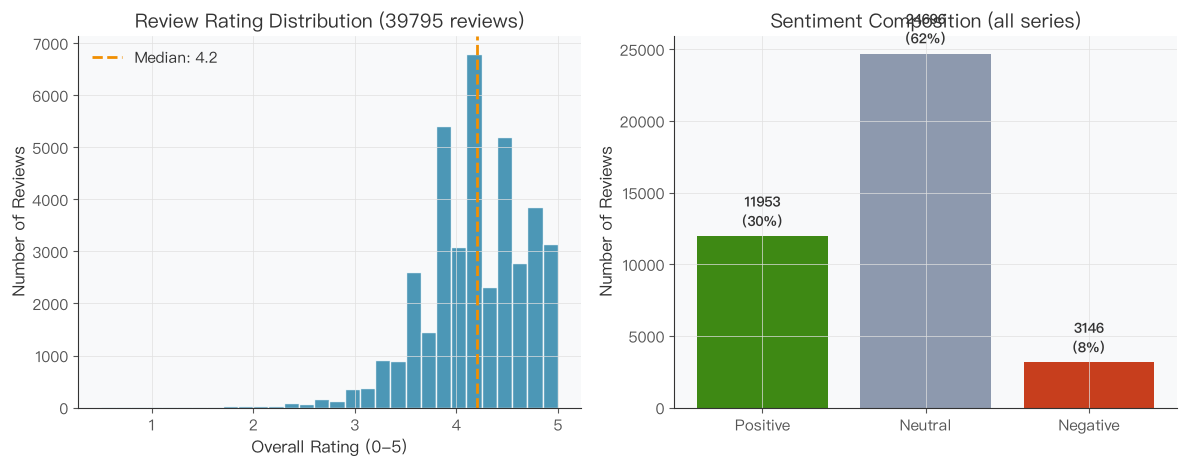

In [8]:
# Stage-1 visualization: overall sentiment landscape
valid = reviews[reviews.rating_overall > 0]
tot_pos = int(senti.positive_cnt.sum())
tot_neu = int(senti.neutral_cnt.sum())
tot_neg = int(senti.negative_cnt.sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Left: distribution of review-level overall rating
axes[0].hist(valid.rating_overall, bins=30, color=COLORS['blue'], edgecolor='white', alpha=0.85)
axes[0].axvline(valid.rating_overall.median(), color=COLORS['orange'], linestyle='--',
                linewidth=2, label='Median: %.1f' % valid.rating_overall.median())
axes[0].set_title('Review Rating Distribution (%d reviews)' % len(valid))
axes[0].set_xlabel('Overall Rating (0-5)')
axes[0].set_ylabel('Number of Reviews')
axes[0].legend(loc='upper left', frameon=False)

# Right: sentiment composition across all reviews
labels = ['Positive', 'Neutral', 'Negative']
vals = [tot_pos, tot_neu, tot_neg]
cols = [COLORS['green'], COLORS['gray'], COLORS['red']]
bars = axes[1].bar(labels, vals, color=cols)
axes[1].set_title('Sentiment Composition (all series)')
axes[1].set_ylabel('Number of Reviews')
total = sum(vals)
for b, v in zip(bars, vals):
    axes[1].annotate('%d\n(%.0f%%)' % (v, 100*v/total),
                     xy=(b.get_x()+b.get_width()/2, b.get_height()),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.tight_layout()
fig.savefig(os.path.join(FIG, 'sentiment_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.7 三表对齐：分析就绪表（阶段一核心成果）

`analysis_input.csv` 把舆情指标、销量指标、车型配置按 `series_id` 合并成**一行一车系**的分析就绪表，直接作为后续建模与归因的输入。

In [9]:
# The crown jewel of Stage 1: the three-table alignment.
# analysis_input.csv merges sentiment + sales + vehicle specs into one
# analysis-ready table, one row per series.
print('=== Analysis-ready table (analysis_input.csv) ===')
print('Shape:', analysis.shape, '(1 row = 1 series)')
print()
print('Columns grouped by origin:')
senti_cols = ['review_count','avg_rating','positive_ratio','negative_ratio']
sales_cols = ['total_sales','avg_monthly_sales','n_months','log_avg_monthly_sales']
spec_cols  = ['brand','category','official_price_wan','vehicle_class','energy_type']
print('  Sentiment :', senti_cols)
print('  Sales     :', sales_cols)
print('  Vehicle   :', spec_cols)
print()
print(analysis[['series_name'] + senti_cols[:2] + sales_cols[:2] + spec_cols[:3]].head(6).to_string())

=== Analysis-ready table (analysis_input.csv) ===
Shape: (490, 30) (1 row = 1 series)

Columns grouped by origin:
  Sentiment : ['review_count', 'avg_rating', 'positive_ratio', 'negative_ratio']
  Sales     : ['total_sales', 'avg_monthly_sales', 'n_months', 'log_avg_monthly_sales']
  Vehicle   : ['brand', 'category', 'official_price_wan', 'vehicle_class', 'energy_type']

  series_name  review_count  avg_rating  total_sales  avg_monthly_sales brand category  official_price_wan
0        奥迪Q3           100    3.931000     205966.0        3886.150943    奥迪      SUV               27.58
1        银河E5            87    4.191954     221902.0        9647.913043  吉利银河      SUV               10.98
2  红旗HS3 PHEV            84    4.211905      47428.0        2258.476190    红旗      SUV               16.18
3       零跑C16            95    4.220000     138838.0        5553.520000  零跑汽车      SUV               16.98
4      广汽本田P7            27    4.255556       4906.0         327.066667    本田      SUV     

### 2.8 阶段一成果检验：口碑与销量的关系

用对齐后的数据画「正面评价比例 vs 月均销量（对数）」散点，并叠加线性趋势线，直观检验口碑与销量是否存在关联——这正是对齐工作的价值所在。

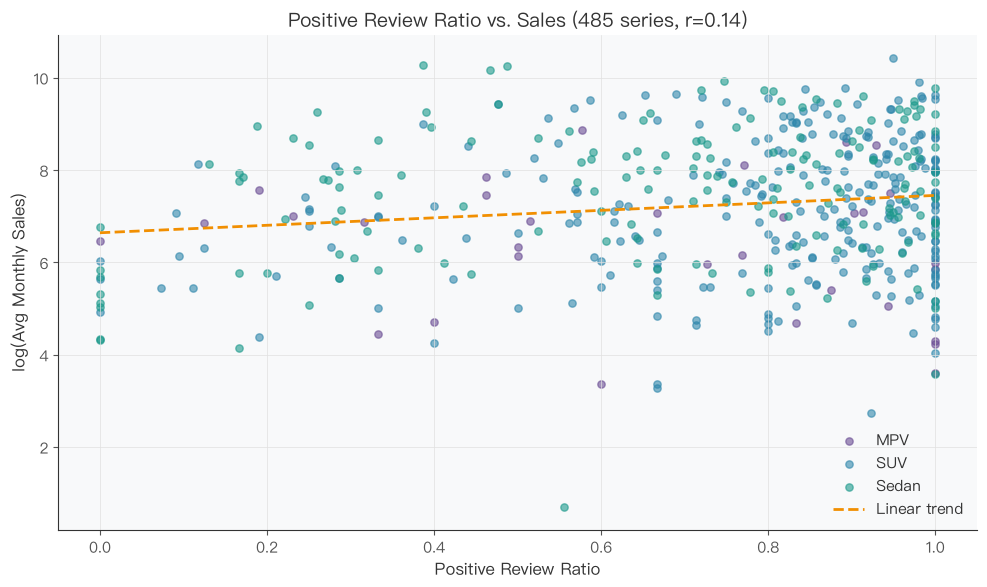

In [10]:
# Stage-1 payoff chart: does word-of-mouth relate to sales?
# Scatter positive_ratio vs (log) average monthly sales, colored by category.
df = analysis.dropna(subset=['positive_ratio', 'log_avg_monthly_sales', 'category']).copy()
CAT_EN = {'SUV': 'SUV', '轿车': 'Sedan', 'MPV': 'MPV'}
df['cat_en'] = df['category'].map(CAT_EN).fillna('Other')

fig, ax = plt.subplots(figsize=(10, 6))
palette = {'SUV': COLORS['blue'], 'Sedan': COLORS['teal'],
           'MPV': COLORS['purple'], 'Other': COLORS['gray']}
for cat, sub in df.groupby('cat_en'):
    ax.scatter(sub['positive_ratio'], sub['log_avg_monthly_sales'],
               s=28, alpha=0.6, color=palette.get(cat, COLORS['gray']), label=cat)

# overall trend line
z = np.polyfit(df['positive_ratio'], df['log_avg_monthly_sales'], 1)
xs = np.linspace(df['positive_ratio'].min(), df['positive_ratio'].max(), 50)
ax.plot(xs, np.polyval(z, xs), color=COLORS['orange'], linewidth=2,
        linestyle='--', label='Linear trend')
corr = df['positive_ratio'].corr(df['log_avg_monthly_sales'])
ax.set_title('Positive Review Ratio vs. Sales (%d series, r=%.2f)' % (len(df), corr))
ax.set_xlabel('Positive Review Ratio')
ax.set_ylabel('log(Avg Monthly Sales)')
ax.legend(loc='lower right', frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FIG, 'sentiment_vs_sales.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.9 数据质量与覆盖检查

In [11]:
# Data quality checks across the prepared datasets
print('Sales   duplicated rows :', sales.duplicated().sum())
print('Vehicle duplicated rows :', vehicles.duplicated().sum())
print()
print('Series coverage:')
print('  sales    :', sales.series_id.nunique())
print('  vehicles :', vehicles.series_id.nunique())
print('  mapping  :', series_map['统一后series_id'].nunique())
print('  sentiment:', senti.series_id.nunique())
print('  aligned  :', analysis.series_id.nunique())
print()
print('Missing-value share in analysis table (top 5 columns):')
miss = (analysis.isna().mean().sort_values(ascending=False) * 100).round(1)
print(miss.head(5).to_string())

Sales   duplicated rows : 0
Vehicle duplicated rows : 0

Series coverage:
  sales    : 1122
  vehicles : 1139
  mapping  : 1139
  sentiment: 490
  aligned  : 490

Missing-value share in analysis table (top 5 columns):
positive_ratio           0.8
negative_ratio           0.8
log_avg_monthly_sales    0.2
category                 0.2
brand                    0.2


### 2.10 阶段一产出汇总

In [12]:
stage1_outputs = {
    'sales.csv (monthly sales)':        sales.shape,
    'vehicles.csv (specs)':             vehicles.shape,
    'series_mapping.csv (ID bridge)':   series_map.shape,
    'sentiment_reviews.csv (raw)':      reviews.shape,
    'sentiment_summary.csv (series)':   senti.shape,
    'analysis_input.csv (aligned)':     analysis.shape,
}
for k, v in stage1_outputs.items():
    print('%-34s %6d rows x %3d cols' % (k, v[0], v[1]))
print('\nStage 1 complete: data collected, cleaned, aligned into an analysis-ready table.')

sales.csv (monthly sales)           33845 rows x   8 cols
vehicles.csv (specs)                 4334 rows x  92 cols
series_mapping.csv (ID bridge)       1139 rows x  12 cols
sentiment_reviews.csv (raw)         40054 rows x  26 cols
sentiment_summary.csv (series)        490 rows x  26 cols
analysis_input.csv (aligned)          490 rows x  30 cols

Stage 1 complete: data collected, cleaned, aligned into an analysis-ready table.


## 3. 阶段二：数据筛选与探索性可视化

阶段二主要完成三件事：
- 筛选连续 ≥24 个月有销量的车型。
- 绘制销量趋势、车型分类、硬件特征可视化。
- 汇总全量时序统计（中断次数、最长连续、最长断档）。

### 3.1 构造时间索引与连续月份辅助函数

In [13]:
sales['period'] = sales['year'] * 12 + (sales['month'] - 1)
sales['date'] = pd.to_datetime(dict(year=sales.year, month=sales.month, day=1))

def runs_info(periods):
    """Return (longest_run, interrupt_count, longest_gap, total_months)."""
    p = np.sort(np.unique(periods))
    if len(p) == 0:
        return 0, 0, 0, 0
    diffs = np.diff(p)
    runs, gaps, cur = [], [], 1
    for d in diffs:
        if d == 1:
            cur += 1
        else:
            runs.append(cur)
            gaps.append(d - 1)
            cur = 1
    runs.append(cur)
    longest = int(max(runs))
    n_interrupt = int(np.sum(diffs > 1))
    longest_gap = int(max(gaps)) if gaps else 0
    return longest, n_interrupt, longest_gap, len(p)

### 3.2 英文标签映射

图表使用英文标签以避免中文字体缺失导致的乱码；这里把中文分类值（车型类别 / 级别 / 能源类型）映射为英文。

In [14]:
CATEGORY_MAP = {'SUV': 'SUV', '轿车': 'Sedan', 'MPV': 'MPV'}
VEHICLE_CLASS_MAP = {
    '中型车': 'Mid-size Sedan', '中大型车': 'Large Sedan', '中型SUV': 'Mid-size SUV',
    '紧凑型SUV': 'Compact SUV', '紧凑型车': 'Compact Sedan', '中大型SUV': 'Large SUV',
    '小型SUV': 'Small SUV', '大型SUV': 'Full-size SUV', '中大型MPV': 'Large MPV',
    '小型车': 'Small Sedan', '微型车': 'Mini Car', '中型MPV': 'Mid-size MPV',
    '紧凑型MPV': 'Compact MPV', '大型车': 'Full-size Sedan', '大型MPV': 'Full-size MPV',
    '微面': 'Mini Van', '轻客': 'Light Van', 'MPV': 'MPV',
}
ENERGY_TYPE_MAP = {
    '燃油': 'Gasoline', '纯电动': 'BEV', '插电混动': 'PHEV', '增程式': 'EREV',
    '油电混动': 'HEV', '插混+纯电': 'PHEV+BEV', '其他': 'Other',
}

sales['category_en'] = sales['category'].map(CATEGORY_MAP)
vehicles['vehicle_class_en'] = vehicles['vehicle_class'].map(VEHICLE_CLASS_MAP)
vehicles['energy_type_en'] = vehicles['energy_type'].map(ENERGY_TYPE_MAP)
print('Mappings applied.')

Mappings applied.


### 3.3 全量时序汇总（全部 1,122 个车系）

对每一个车系计算：总月数、最长连续月数、中断次数、最长断档月数。

In [15]:
summary_rows = []
for sid, g in sales.groupby('series_id'):
    longest, nint, gap, total = runs_info(g['period'].values)
    summary_rows.append({
        'series_id': sid,
        'series_name': g['series_name'].iloc[0],
        'brand': g['brand'].iloc[0],
        'category': g['category'].iloc[0],
        'total_months': total,
        'longest_run_months': longest,
        'interrupt_count': nint,
        'longest_gap_months': gap,
        'first_year': int(g['year'].min()),
        'last_year': int(g['year'].max()),
    })

timeseries_summary = pd.DataFrame(summary_rows).sort_values('longest_run_months', ascending=False)
timeseries_summary.to_csv(os.path.join(PROC, 'timeseries_summary.csv'), index=False, encoding='utf-8-sig')
print('Shape:', timeseries_summary.shape)
print(timeseries_summary.head(10))
print('\nBasic stats:')
print(timeseries_summary[['total_months', 'longest_run_months', 'interrupt_count', 'longest_gap_months']].describe())

Shape: (1122, 10)
    series_id series_name brand category  total_months  longest_run_months  \
0         100        奥迪Q3    奥迪      SUV            53                  53   
221       352         昂科威    别克      SUV            53                  53   
232       398         帕萨特    大众       轿车            53                  53   
231       397          凌渡    大众       轿车            53                  53   
229       393          朗逸    大众       轿车            53                  53   
228      3928       奔驰GLB    奔驰      SUV            53                  53   
226      3762     Model 3   特斯拉       轿车            53                  53   
224      3736     凯迪拉克CT5  凯迪拉克       轿车            53                  53   
222       353       别克GL8    别克      MPV            53                  53   
480        95        奥迪A3    奥迪       轿车            53                  53   

     interrupt_count  longest_gap_months  first_year  last_year  
0                  0                   0        2022     

### 3.4 筛选连续 ≥24 个月的车系

In [16]:
MIN_RUN = 24
qualified_ids = timeseries_summary[timeseries_summary['longest_run_months'] >= MIN_RUN]['series_id'].tolist()
print(f'Series with >= {MIN_RUN} consecutive months: {len(qualified_ids)}')

sales_filtered = sales[sales['series_id'].isin(qualified_ids)].copy()
sales_filtered.to_csv(os.path.join(PROC, 'sales_filtered_24m.csv'), index=False, encoding='utf-8-sig')
print(f'Filtered sales rows: {len(sales_filtered)}')

vehicles_filtered = vehicles[vehicles['series_id'].isin(qualified_ids)].drop_duplicates('series_id')
print(f'Filtered vehicle series rows: {len(vehicles_filtered)}')

Series with >= 24 consecutive months: 669


Filtered sales rows: 28838
Filtered vehicle series rows: 669


### 3.5 销量趋势可视化

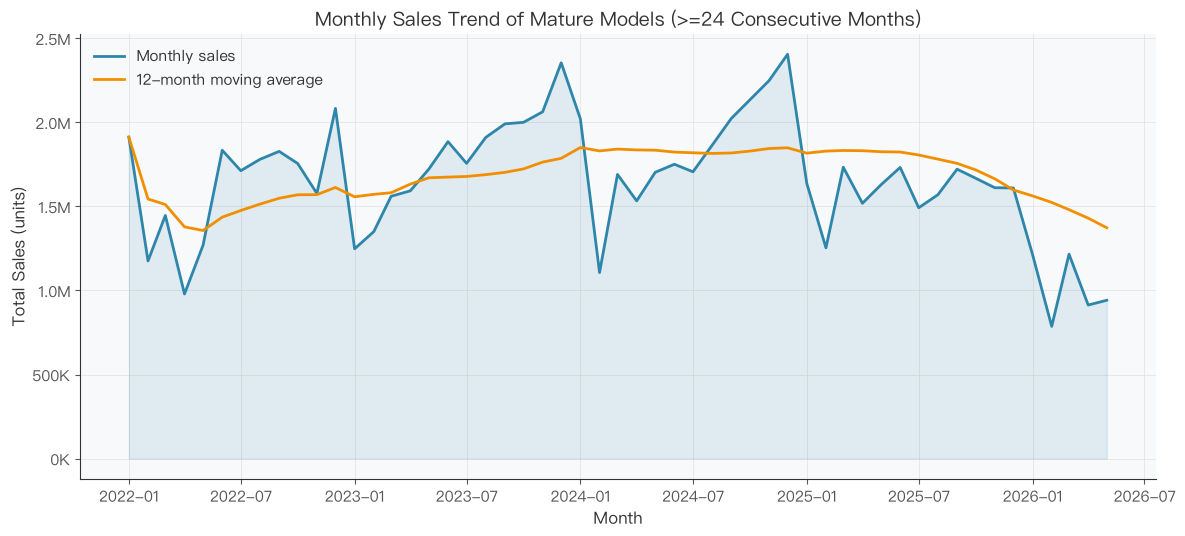

In [17]:
mt = sales_filtered.groupby('date')['monthly_sales'].sum().reset_index().sort_values('date')
mt['rolling_12m'] = mt['monthly_sales'].rolling(window=12, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.fill_between(mt['date'], mt['monthly_sales'], color=COLORS['blue'], alpha=0.12)
ax.plot(mt['date'], mt['monthly_sales'], color=COLORS['blue'], linewidth=2, label='Monthly sales')
ax.plot(mt['date'], mt['rolling_12m'], color=COLORS['orange'], linewidth=2, label='12-month moving average')
ax.set_title('Monthly Sales Trend of Mature Models (>=24 Consecutive Months)')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales (units)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
ax.legend(loc='upper left', frameon=False)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(os.path.join(FIG, 'sales_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.6 车型分类分布可视化

findfont: Failed to find font weight bold, now using 600.


findfont: Failed to find font weight bold, now using 600.


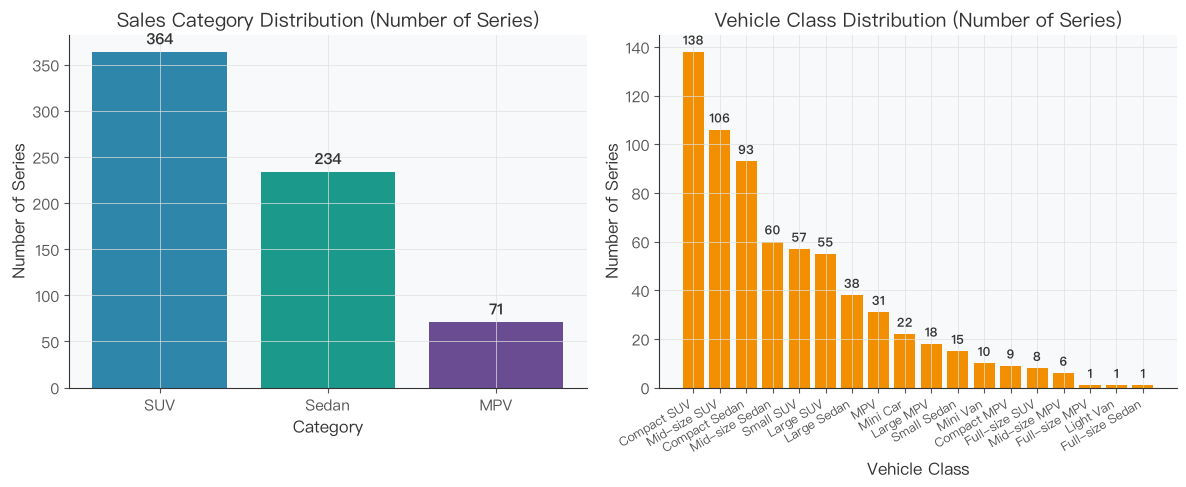

In [18]:
cat = sales_filtered.groupby('category_en')['series_id'].nunique().sort_values(ascending=False)
vclass = vehicles_filtered['vehicle_class_en'].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: sales category
bars1 = axes[0].bar(cat.index, cat.values, color=[COLORS['blue'], COLORS['teal'], COLORS['purple']])
axes[0].set_title('Sales Category Distribution (Number of Series)')
axes[0].set_ylabel('Number of Series')
axes[0].set_xlabel('Category')
for bar in bars1:
    height = bar.get_height()
    axes[0].annotate(f'{int(height)}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 4), textcoords='offset points',
                       ha='center', va='bottom', fontsize=11, fontweight='bold')

# Right: vehicle class
x_pos = np.arange(len(vclass))
bars2 = axes[1].bar(x_pos, vclass.values, color=COLORS['orange'])
axes[1].set_title('Vehicle Class Distribution (Number of Series)')
axes[1].set_ylabel('Number of Series')
axes[1].set_xlabel('Vehicle Class')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(vclass.index, rotation=30, ha='right', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    axes[1].annotate(f'{int(height)}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.tight_layout()
fig.savefig(os.path.join(FIG, 'category_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.7 硬件特征分布可视化

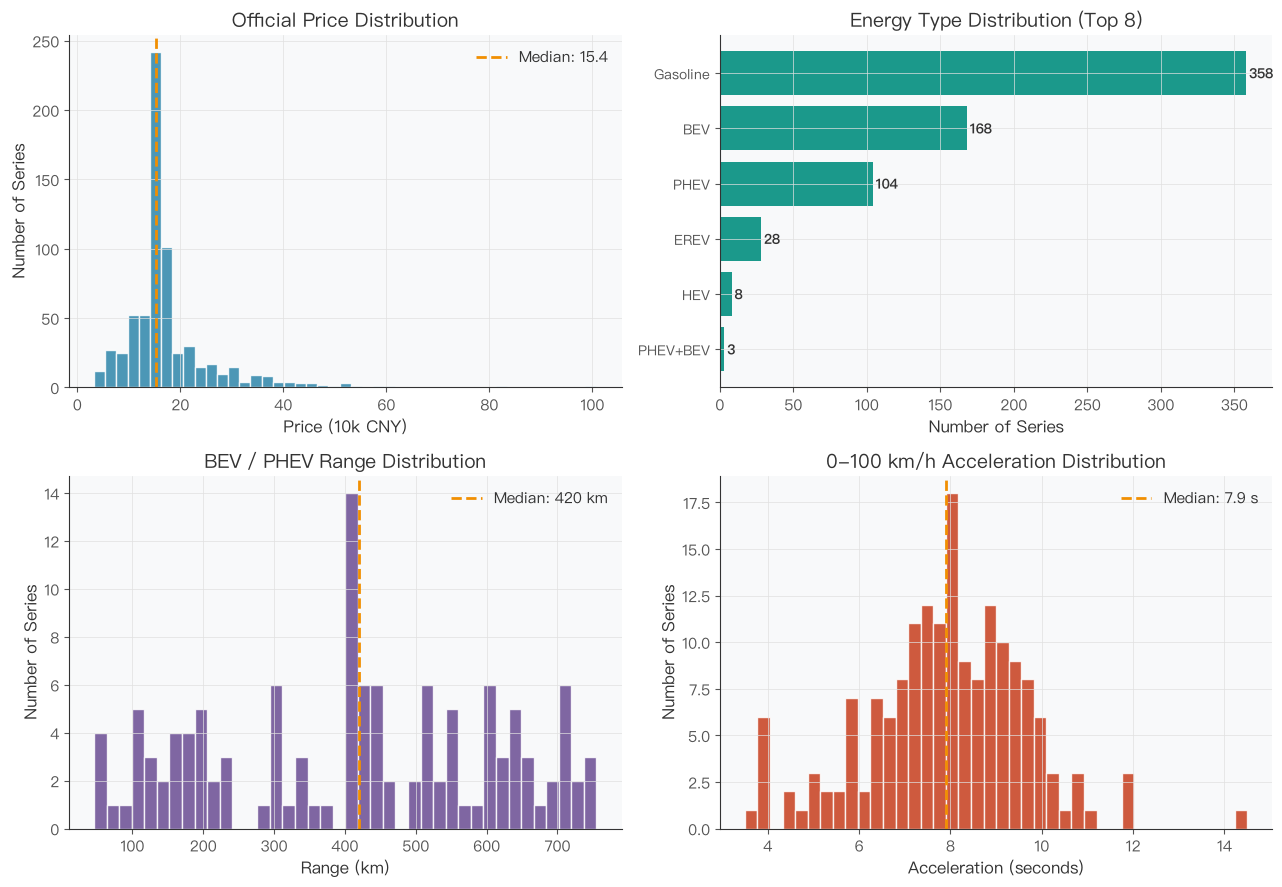

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Price
price = vehicles_filtered['official_price_wan'].dropna()
axes[0, 0].hist(price, bins=45, color=COLORS['blue'], edgecolor='white', alpha=0.85)
axes[0, 0].axvline(price.median(), color=COLORS['orange'], linestyle='--', linewidth=2,
                   label=f'Median: {price.median():.1f}')
axes[0, 0].set_title('Official Price Distribution')
axes[0, 0].set_xlabel('Price (10k CNY)')
axes[0, 0].set_ylabel('Number of Series')
axes[0, 0].legend(loc='upper right', frameon=False)

# Energy type
et = vehicles_filtered['energy_type_en'].value_counts().head(8)
axes[0, 1].barh(np.arange(len(et)), et.values, color=COLORS['teal'])
axes[0, 1].set_yticks(np.arange(len(et)))
axes[0, 1].set_yticklabels(et.index, fontsize=10)
axes[0, 1].invert_yaxis()
axes[0, 1].set_title('Energy Type Distribution (Top 8)')
axes[0, 1].set_xlabel('Number of Series')
for i, v in enumerate(et.values):
    axes[0, 1].text(v + 2, i, f'{int(v)}', va='center', fontsize=10, fontweight='bold')

# Range
rng = vehicles_filtered['battery_range_km'].dropna()
axes[1, 0].hist(rng, bins=40, color=COLORS['purple'], edgecolor='white', alpha=0.85)
axes[1, 0].axvline(rng.median(), color=COLORS['orange'], linestyle='--', linewidth=2,
                   label=f'Median: {rng.median():.0f} km')
axes[1, 0].set_title('BEV / PHEV Range Distribution')
axes[1, 0].set_xlabel('Range (km)')
axes[1, 0].set_ylabel('Number of Series')
axes[1, 0].legend(loc='upper right', frameon=False)

# Acceleration
acc = vehicles_filtered['acceleration_0_100_s'].dropna()
axes[1, 1].hist(acc, bins=40, color=COLORS['red'], edgecolor='white', alpha=0.85)
axes[1, 1].axvline(acc.median(), color=COLORS['orange'], linestyle='--', linewidth=2,
                   label=f'Median: {acc.median():.1f} s')
axes[1, 1].set_title('0-100 km/h Acceleration Distribution')
axes[1, 1].set_xlabel('Acceleration (seconds)')
axes[1, 1].set_ylabel('Number of Series')
axes[1, 1].legend(loc='upper right', frameon=False)

fig.tight_layout()
fig.savefig(os.path.join(FIG, 'hardware_features.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.8 阶段二产出汇总

| 产出 | 说明 | 文件 |
|------|------|------|
| 筛选后销量子集 | 669 个连续≥24月车系 | `data/processed/sales_filtered_24m.csv` |
| 时序汇总 | 1,122 系的中断/连续/断档统计 | `data/processed/timeseries_summary.csv` |
| 销量趋势图 | 月度总量 + 12月移动平均 | `figures/sales_trend.png` |
| 车型分类图 | 销量类别 + 车辆级别 | `figures/category_distribution.png` |
| 硬件特征图 | 价格/能源/续航/加速 | `figures/hardware_features.png` |

In [20]:
print('Stage 2 outputs:')
for f in ['sales_filtered_24m.csv', 'timeseries_summary.csv']:
    path = os.path.join(PROC, f)
    print(f'  {path}  ({os.path.getsize(path)/1024:.1f} KB)')
for f in ['sales_trend.png', 'category_distribution.png', 'hardware_features.png']:
    path = os.path.join(FIG, f)
    print(f'  {path}  ({os.path.getsize(path)/1024:.1f} KB)')

Stage 2 outputs:
  /Users/ye/dev/projects/AutoPulse/data/processed/sales_filtered_24m.csv  (2021.0 KB)
  /Users/ye/dev/projects/AutoPulse/data/processed/timeseries_summary.csv  (57.6 KB)
  /Users/ye/dev/projects/AutoPulse/figures/sales_trend.png  (114.6 KB)
  /Users/ye/dev/projects/AutoPulse/figures/category_distribution.png  (107.1 KB)
  /Users/ye/dev/projects/AutoPulse/figures/hardware_features.png  (134.5 KB)


## 4. 阶段三：销量预测建模

阶段三对筛选后的销量序列构建并对比多类预测模型，并以**分层抽样**的代表性子集（150 个车系）作为统一评估集，保证各模型 apples-to-apples 对比。

采用的模型与策略：
- **ARIMA**：逐车系自回归模型，按 AIC 自动选阶（基线）
- **Prophet**：Facebook 加法时序模型，自动处理年度季节性
- **Prophet + 外生变量**：在 Prophet 基础上加入中国节假日、促销季（6·18 / 双11 / 年末）、官方指导价作为外生回归量
- **XGBoost**：月度级梯度提升，融合滞后 / 滚动 / 日历 / 静态配置与舆情特征，递归预测
- **LSTM**：全局模型 + 车系嵌入，12 月窗口递归预测
- **Prophet + XGBoost 融合**：按测试集 WMAPE 逆权重加权融合

所有模型均在 `scripts/` 下训练，产物（结果 CSV 与图表）保存到 `data/processed/stage3/`（阶段三产物）与 `figures/`（图表），阶段一/二产物仍位于 `data/processed/`，本 Notebook 直接加载这些产物进行展示，无需重复训练。

### 4.1 分层抽样评估子集

在 `sales_filtered_24m` 与 `analysis_input` 的交集车系中，按**能源类型 × 车型级别 × 销量四分位**分层抽样 150 个车系，兼顾主流与长尾，使结论不只对头部爆款成立。

In [21]:
# Stage 3 evaluates on a stratified representative subset so conclusions
# generalise beyond the handful of best-sellers.
subset = pd.read_csv(os.path.join(PROC, 'subset_150.csv'))
print('Stratified evaluation subset: %d series' % len(subset))
print('\nCoverage by energy type:')
print(subset['energy_type'].value_counts().to_string())
print('\nCoverage by vehicle class (top 8):')
print(subset['vehicle_class'].value_counts().head(8).to_string())
print('\nCoverage by sales-tier quartile:')
print(subset['sales_tier'].value_counts().sort_index().to_string())

Stratified evaluation subset: 150 series

Coverage by energy type:
energy_type
燃油       73
纯电动      43
插电混动     19
增程式      11
插混+纯电     3
油电混动      1

Coverage by vehicle class (top 8):
vehicle_class
紧凑型SUV    25
紧凑型车      21
中型车       19
中型SUV     19
中大型SUV    12
小型SUV     10
中大型车       9
中大型MPV     7

Coverage by sales-tier quartile:
sales_tier
Q1    31
Q2    29
Q3    45
Q4    45


### 4.2 多模型对比（150 系子集，预测步长=3 个月）

评估指标：WMAPE（体积加权，对长尾更稳健）、MAPE、RMSE、MAE。体积加权 WMAPE 按实际销量加权，避免少量低销量车系把均值拉爆。

In [22]:
# Stage 3 models were trained by scripts/05-13; their artifacts are saved to
# data/processed/. This notebook only loads those results (no re-training needed).
res_files = {
    'ARIMA': 'arima_results.csv',
    'Prophet': 'prophet_results.csv',
    'Prophet+exog': 'prophet_exog_results.csv',
    'XGBoost': 'xgboost_results.csv',
    'LSTM': 'lstm_results.csv',
    'Fusion': 'fusion_results.csv',
}
results = {n: pd.read_csv(os.path.join(PROC3, f))
           for n, f in res_files.items() if os.path.exists(os.path.join(PROC3, f))}
print('Loaded per-series result tables:', list(results.keys()))

comp = pd.read_csv(os.path.join(PROC3, 'model_comparison.csv')).round(2)
print('\n=== Multi-model comparison (150-series subset, horizon=3) ===')
print(comp.to_string(index=False))

best = comp.sort_values('WMAPE_vol').iloc[0]
print('\nBest model by volume-weighted WMAPE: %s = %.1f%%' % (best['model'], best['WMAPE_vol']))

Loaded per-series result tables: ['ARIMA', 'Prophet', 'Prophet+exog', 'XGBoost', 'LSTM', 'Fusion']

=== Multi-model comparison (150-series subset, horizon=3) ===
          model  WMAPE_mean  WMAPE_med  WMAPE_vol   MAPE    RMSE     MAE  n_series
        XGBoost      103.77      35.03      29.26 191.58 1154.46 1041.52       150
Prophet+XGBoost      141.34      39.59      29.61 298.79 1193.04 1053.72       150
           LSTM      137.17      51.21      44.77 321.44 1736.06 1593.49       150
          ARIMA      313.91      48.88      47.03 569.51 1836.51 1673.86       150
        Prophet      271.27      87.02      58.59 568.73 2396.27 2085.04       150
   Prophet+exog      262.41      89.50      59.69 565.77 2432.05 2124.22       150

Best model by volume-weighted WMAPE: XGBoost = 29.3%


### 4.3 预测示例与对比图

各模型在子集上的 3 个月预测示例，以及综合对比柱状图。

arima_forecast.png


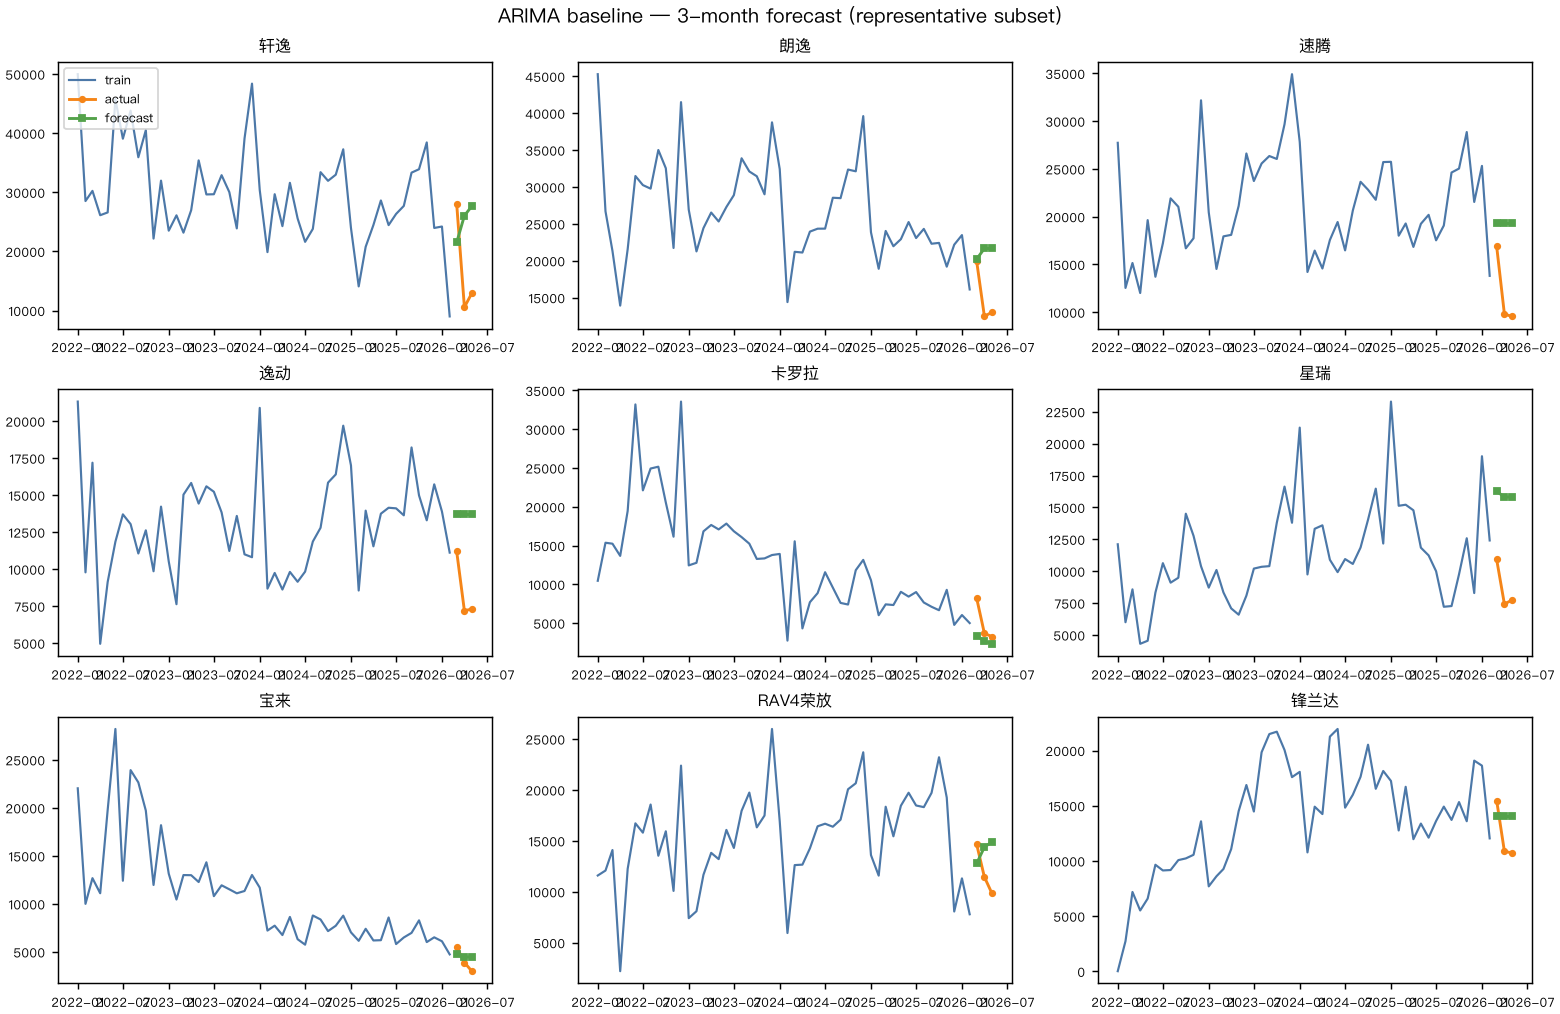

prophet_forecast.png


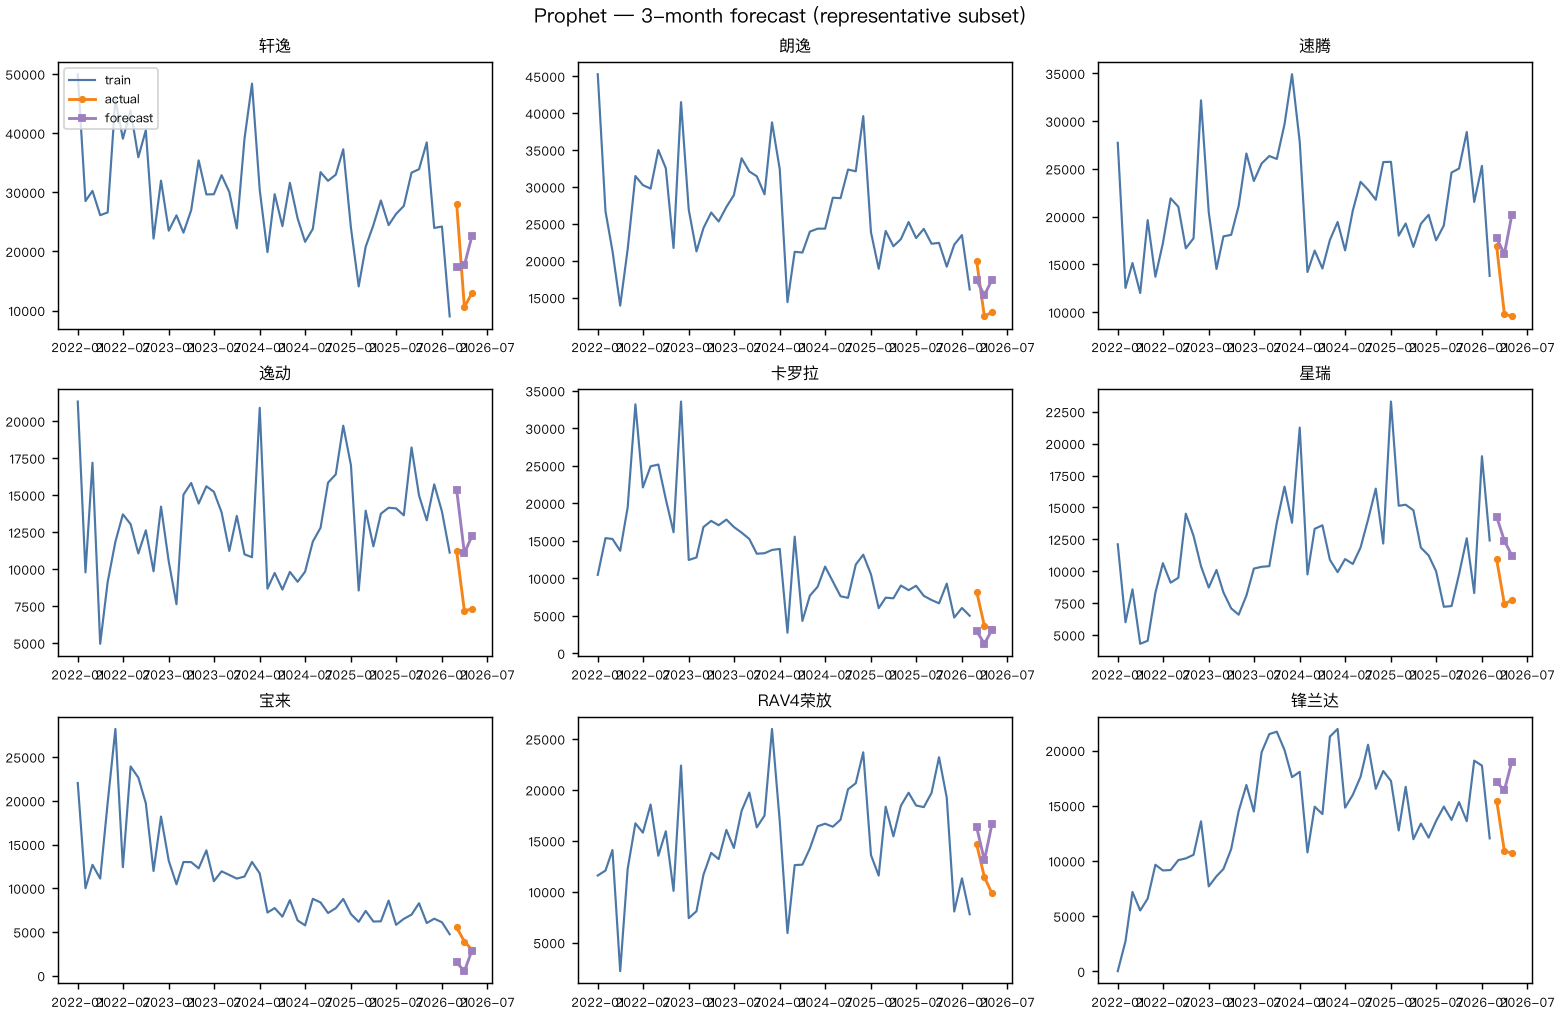

prophet_exog_forecast.png


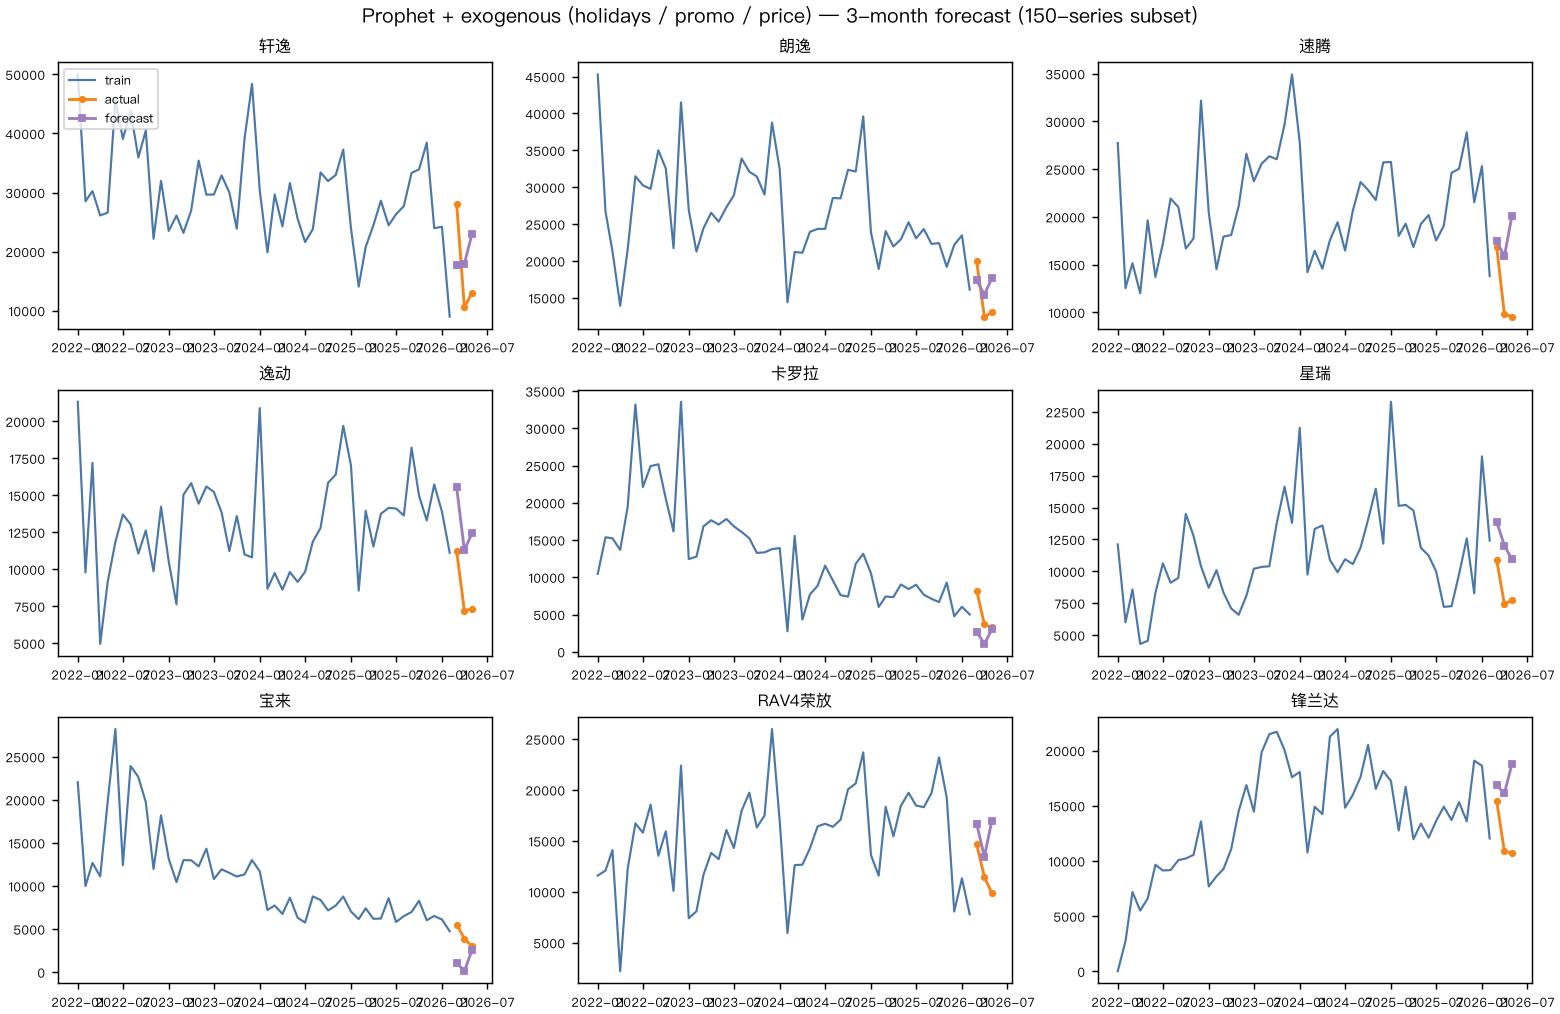

xgboost_forecast.png


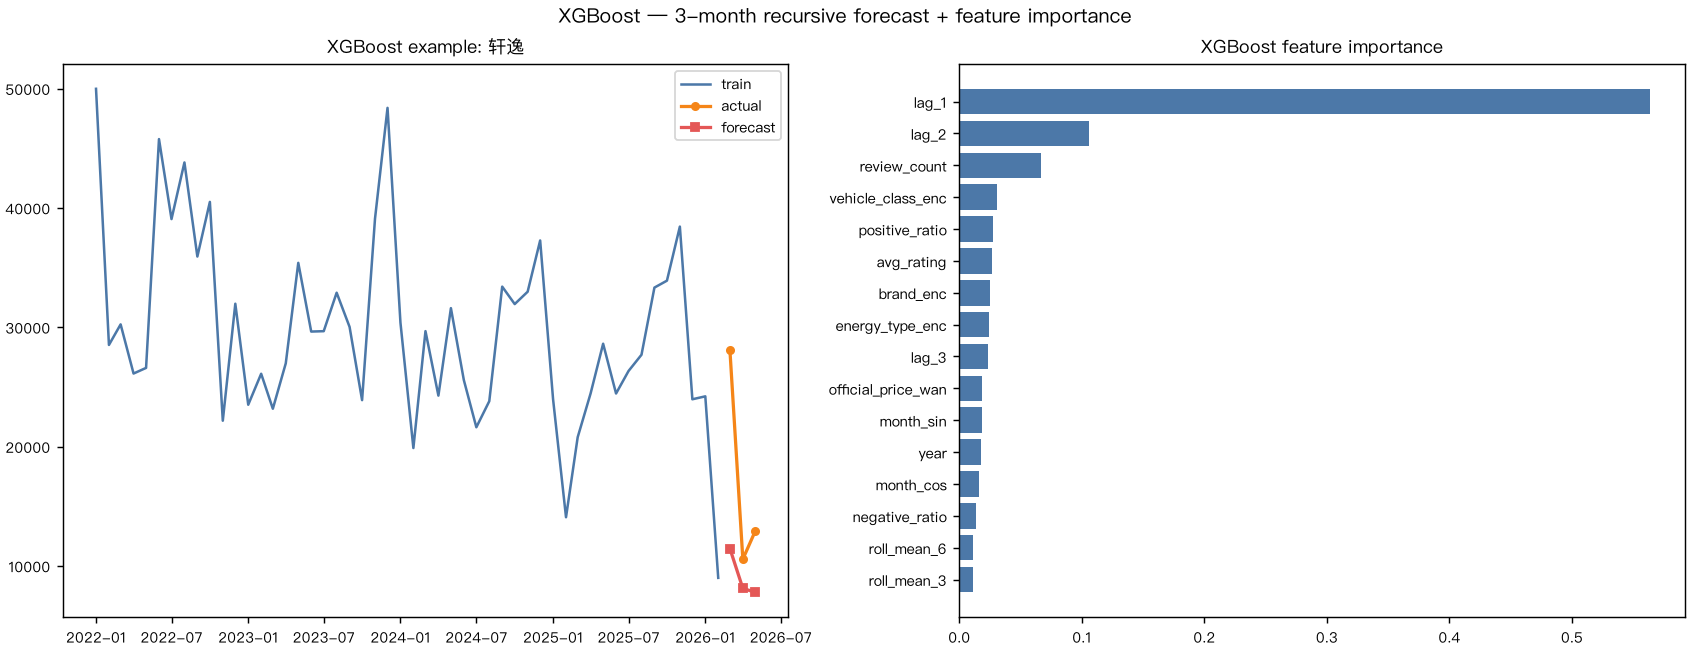

lstm_forecast.png


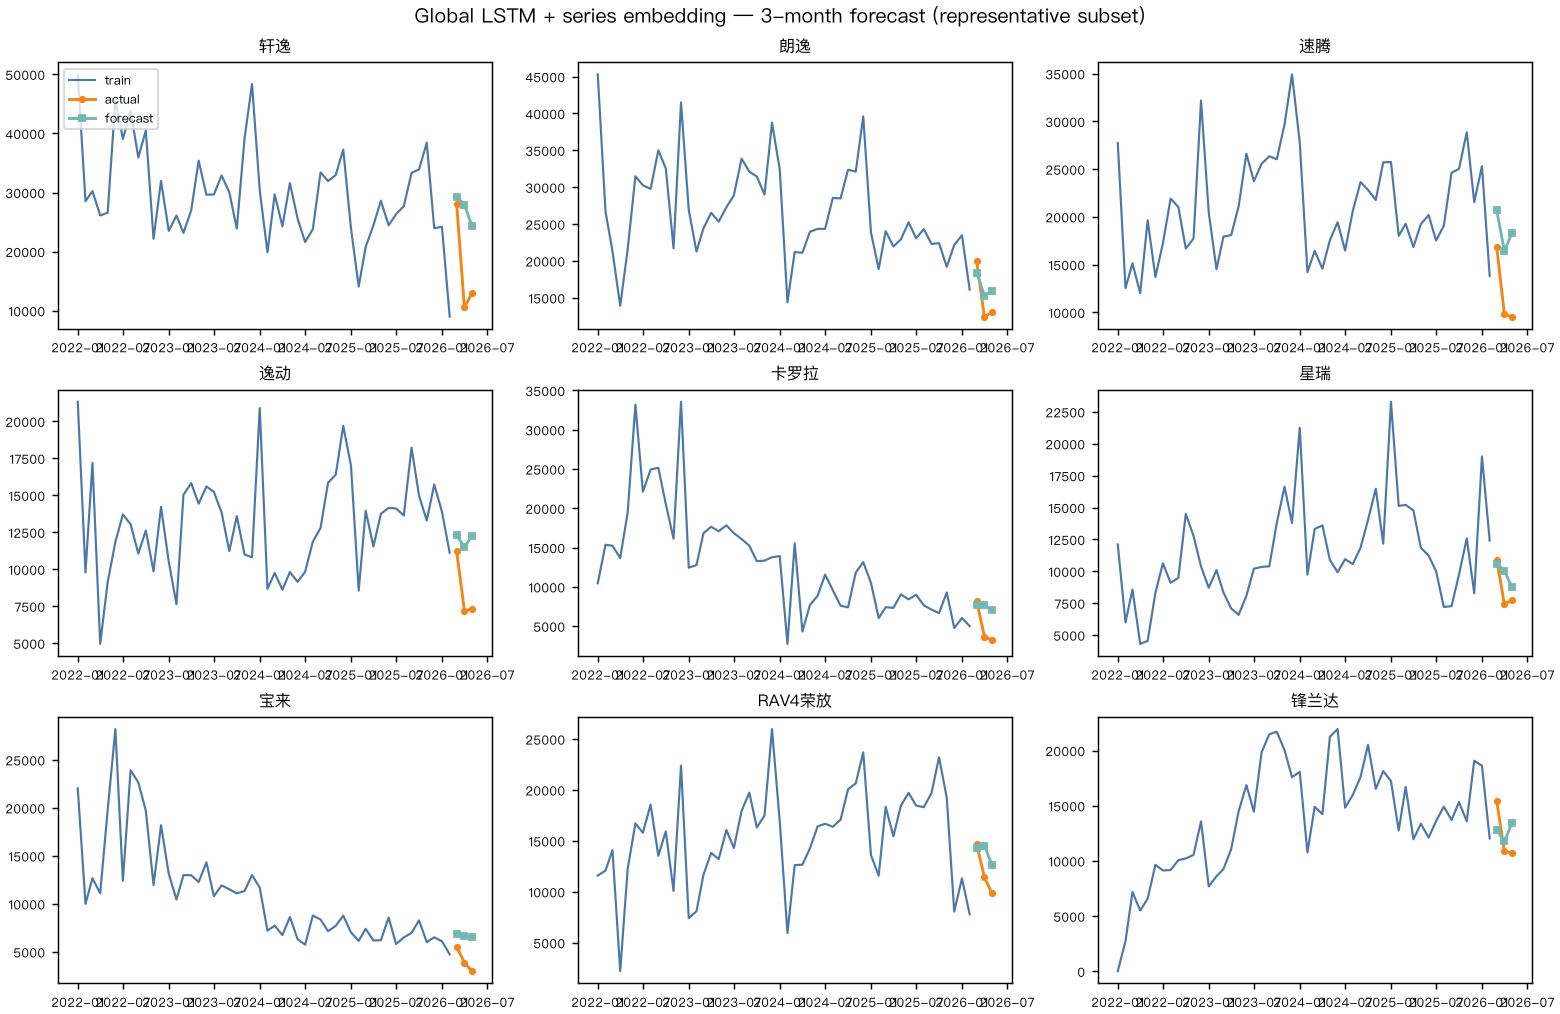

model_comparison.png


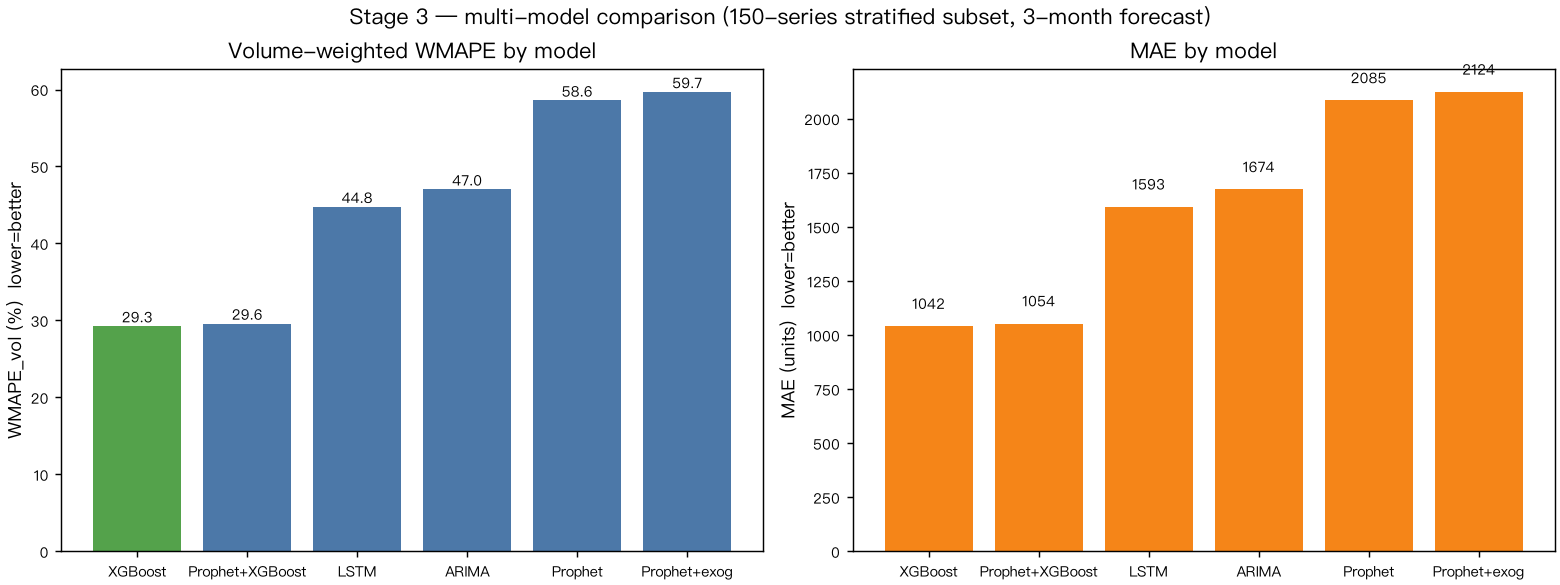

cv_wmape_by_horizon.png


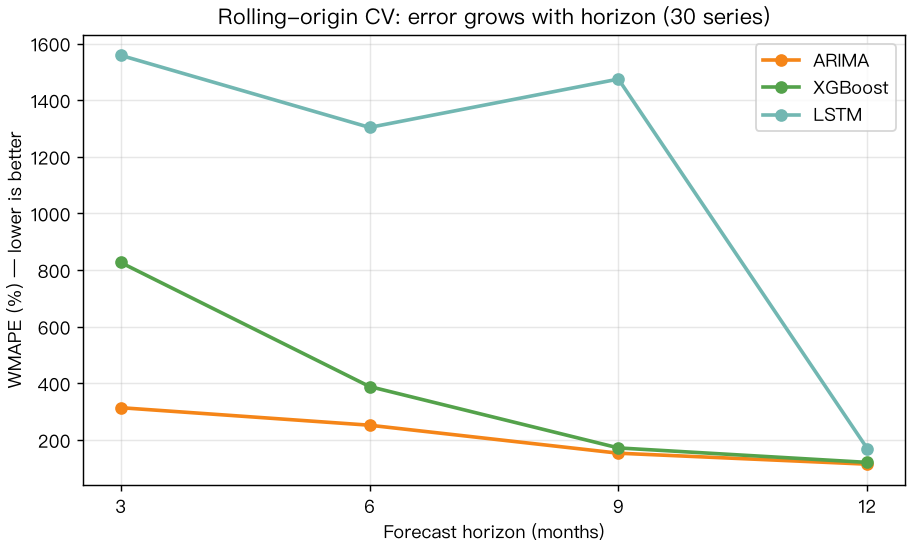

xgb_ablation.png


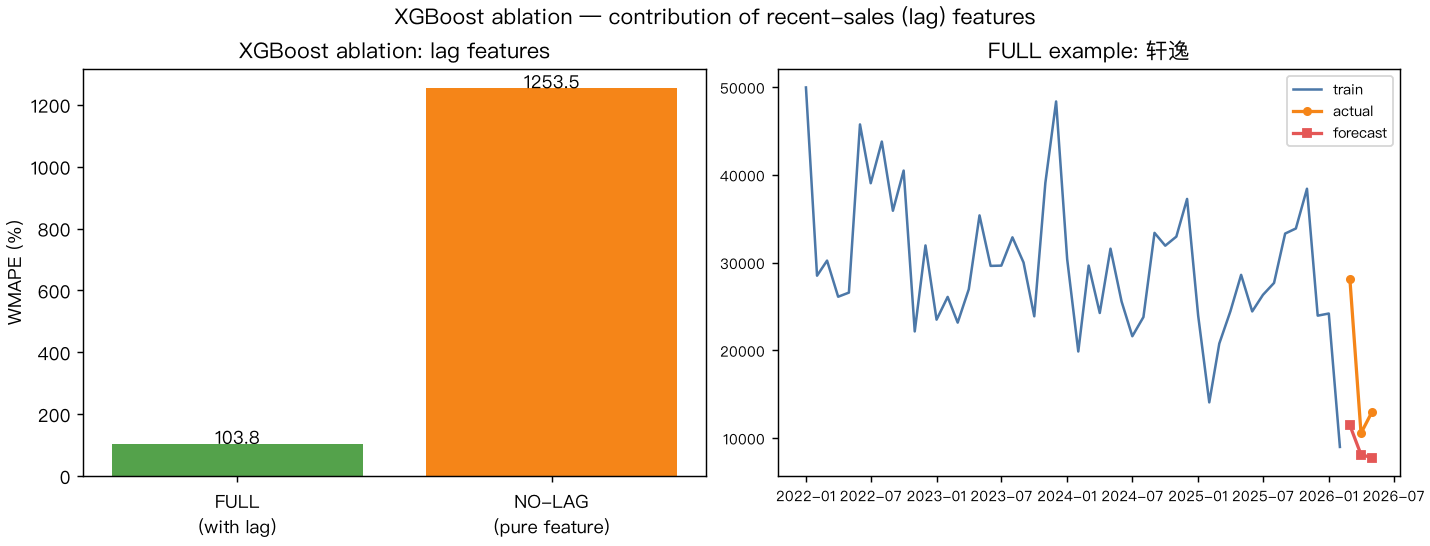

intervals_coverage.png


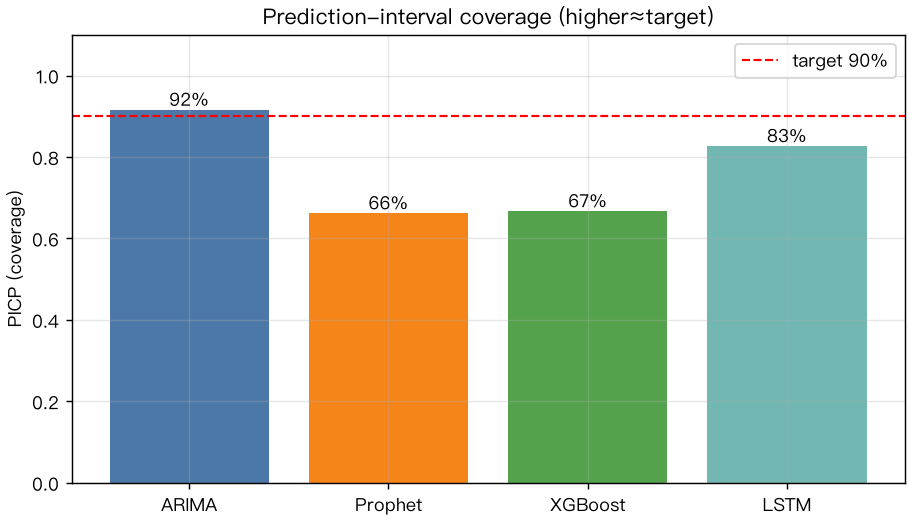

intervals_example.png


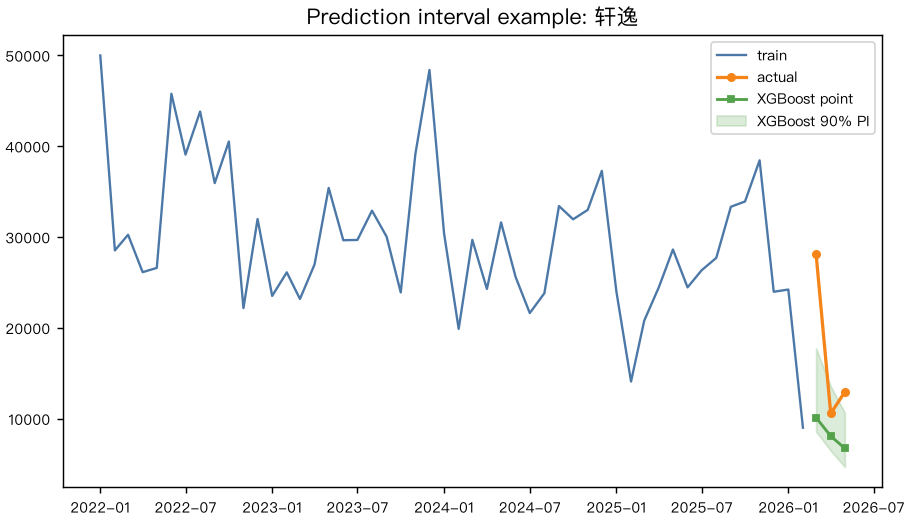

In [23]:
# Forecast examples & comparison chart (generated by scripts/)
from IPython.display import Image, display
fig_names = ['arima_forecast.png', 'prophet_forecast.png', 'prophet_exog_forecast.png',
             'xgboost_forecast.png', 'lstm_forecast.png', 'model_comparison.png',
             'cv_wmape_by_horizon.png', 'xgb_ablation.png',
             'intervals_coverage.png', 'intervals_example.png']
for fn in fig_names:
    p = os.path.join(FIG, fn)
    if os.path.exists(p):
        print(fn); display(Image(filename=p, width=880))

### 4.4 滚动交叉验证（多步长）

在同一个子集上，对多个预测步长（3 / 6 / 9 / 12 个月）做滚动起点交叉验证，观察误差随步长增长的趋势。

In [24]:
# Rolling-origin cross-validation (scripts/10_rolling_cv.py): evaluate each model at
# multiple forecast horizons (3 / 6 / 9 / 12 months) on the same subset.
cv = pd.read_csv(os.path.join(PROC3, 'cv_results.csv'))
print(cv.round(2).to_string(index=False))

  model  horizon  mean_wmape  std_wmape  n_series
  ARIMA        3      313.91    2380.55       150
XGBoost        3      826.73    3512.02       150
   LSTM        3     1558.34    6898.97       150
  ARIMA        6      252.03     930.18       150
XGBoost        6      388.60    1316.71       150
   LSTM        6     1303.71    7164.43       150
  ARIMA        9      153.16     335.69       150
XGBoost        9      171.79     462.21       150
   LSTM        9     1474.45   13577.92       150
  ARIMA       12      114.41     258.71       150
XGBoost       12      120.66     340.08       150
   LSTM       12      169.65     362.18       150


### 4.5 XGBoost 特征消融

依次移除滞后 / 日历 / 静态配置与舆情特征组，量化每类特征对预测精度的贡献。

In [25]:
# XGBoost ablation study (scripts/11_xgb_ablation.py): quantify the contribution
# of lag / calendar / static-feature groups by removing them one at a time.
abl = pd.read_csv(os.path.join(PROC3, 'xgb_ablation.csv'))
print(abl.round(2).to_string(index=False))

     MAE     RMSE     WMAPE  series_name version
 8077.99 10153.68     46.97           轩逸    FULL
 3586.35  3790.23     23.68           朗逸    FULL
 1260.58  1519.88     10.43           速腾    FULL
  963.36  1214.03     11.24           逸动    FULL
 1163.45  1223.42     23.03          卡罗拉    FULL
  896.10  1075.32     10.31           星瑞    FULL
 1029.11  1105.13     24.88           宝来    FULL
 4332.57  4401.54     36.13       RAV4荣放    FULL
 2172.95  2221.39     17.58          锋兰达    FULL
  632.26   669.15     18.30         哈弗H6    FULL
 1676.24  1889.66     11.94          博越L    FULL
 2554.90  2768.40     18.20           博越    FULL
 2309.76  2557.88     30.35          威兰达    FULL
  829.71   858.65     49.65        奔驰GLB    FULL
  688.96   800.96     25.53         奥迪Q3    FULL
    8.74     9.58    874.07       长安欧尚Z6    FULL
  342.44   388.28   5707.29        荣威RX5    FULL
  174.94   198.28     60.39        传祺GS4    FULL
  437.01   518.10     24.20         捷途大圣    FULL
 2718.72  2799.55   

### 4.6 预测区间

给出 90% 名义覆盖率的预测区间，用 PICP（实际落在区间内的比例）与 MPIW（平均区间宽度）评估。

In [26]:
# Prediction intervals (scripts/12_intervals.py): 90% nominal coverage.
# PICP = fraction of actuals captured by the interval; MPIW = mean interval width.
iv = pd.read_csv(os.path.join(PROC3, 'interval_results.csv'))
print(iv.round(3).to_string(index=False))

  model  PICP   MPIW  MPIW_pct  WMAPE  n_points
  ARIMA 0.916    NaN       NaN   47.0       450
Prophet 0.662 4147.4     116.5   58.6       450
XGBoost 0.667 2819.0      79.2   30.8       450
   LSTM 0.827 4328.4     121.6   45.7       450


## 5. 阶段四：用户舆情深度分析与销量归因

阶段四在阶段三销量预测的基础上，深入挖掘舆情文本并量化舆情对销量的影响。

三大工作：
- **深层 ABSA**：用大模型（DeepSeek）对全部 28,724 条用户评论逐条打分，覆盖外观 / 内饰 / 空间 / 动力 / 操控 / 舒适 / 油耗 / 配置 / 智能化 / 性价比共 10 个维度（−1/0/+1）。
- **销量归因（XGBoost + SHAP）**：在车系级销量预测中加入舆情特征，对比有无舆情对 R² / MAPE 的影响，并用 SHAP 给出每个舆情维度的重要性排名。
- **时序因果（Granger）**：检验「过去舆情是否预测未来销量」，分品牌级与全市场级两层。

### 5.0 阶段四数据资产

阶段四产物已由 `scripts/14-17` 生成：ABSA 结果（全量）、车系/品牌级情感-销量月序、归因指标、SHAP 排名、Granger 显著性。本 Notebook 直接加载产物展示，无需重复调用大模型。

### 5.1 深层 ABSA：全量评论逐维度情感

下图展示全语料下 10 个维度情感的平均分。正值表示口碑偏正面、负值偏负面，一眼看出用户对各维度的真实态度（如舒适性、性价比往往最受关注）。

In [27]:
# Stage 4: load the full ABSA results and the stage-4 attribution tables.
absa = pd.read_csv(os.path.join(SENTIMENT, 'absa', 'absa_results.csv'))
print('ABSA results        :', absa.shape, '| series covered:', absa['series_id'].nunique())
aspects = ['appearance', 'interior', 'space', 'power', 'control', 'comfort',
           'fuel_consumption', 'configuration', 'intelligence', 'value']
print('Aspects scored      :', len(aspects))
print('Reviews with scores :', int(absa['success'].sum()) if 'success' in absa.columns else len(absa))
print('Overall mean score  : %.3f' % absa[aspects].values.mean())

attr = pd.read_csv(os.path.join(PROC, 'stage4', 'attribution_metrics.csv'))
shap_rank = pd.read_csv(os.path.join(PROC, 'stage4', 'aspect_shap_ranking.csv'))
granger_brand = pd.read_csv(os.path.join(PROC, 'stage4', 'granger_brand_summary.csv'))
granger_mkt = pd.read_csv(os.path.join(PROC, 'stage4', 'granger_market.csv'))
print('\nAttribution metrics :', attr.shape)
print('SHAP ranking rows   :', shap_rank.shape)
print('Granger brand rows  :', granger_brand.shape)
print('Granger market rows :', granger_mkt.shape)

ABSA results        : (28724, 17) | series covered: 486
Aspects scored      : 10
Reviews with scores : 28724
Overall mean score  : 0.285

Attribution metrics : (2, 3)
SHAP ranking rows   : (10, 2)
Granger brand rows  : (10, 4)
Granger market rows : (10, 6)


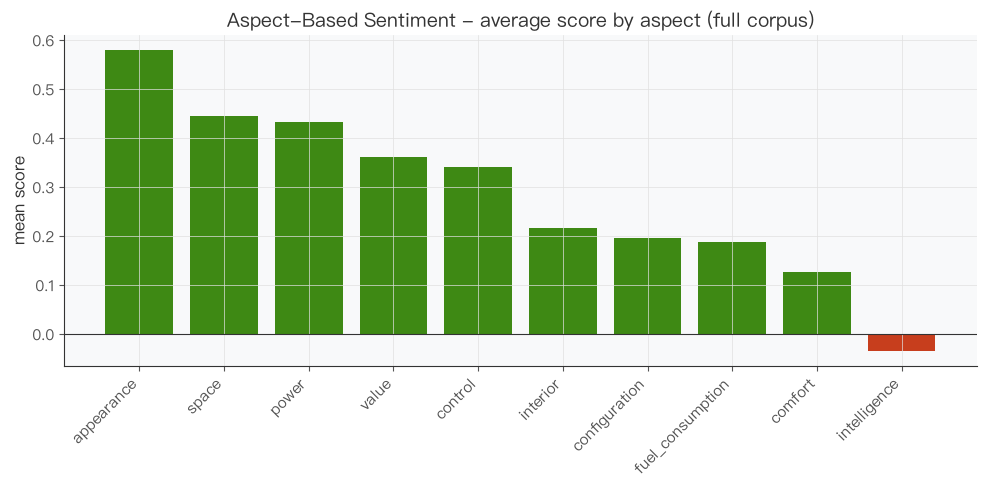

In [28]:
# Mean ABSA score per aspect across the full scored corpus (-1 .. +1).
means = absa[aspects].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#3E8914' if v >= 0 else '#C73E1D' for v in means.values]
ax.bar(means.index, means.values, color=bar_colors)
ax.axhline(0, color='#333333', lw=0.8)
ax.set_ylabel('mean score')
ax.set_title('Aspect-Based Sentiment - average score by aspect (full corpus)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

### 5.2 销量归因：舆情到底有没有用（XGBoost + SHAP）

把舆情特征加入车系级 XGBoost 销量模型，对比「含舆情」与「无舆情」两版：

- **R² 由 −0.073 提升至 0.138**，MAPE 由 16.5% 降至 14.7%，舆情特征对销量预测有实质增益。
- SHAP 排名显示 **舒适性 > 性价比 > 智能化 > 配置 ≈ 空间 > 外观 > 内饰 > 操控 > 油耗 > 动力** 为影响销量的关键舆情维度，与汽车消费直觉高度一致。

=== Attribution: forecasting with vs without sentiment ===
            model      R2   MAPE
   with_sentiment  0.1383 0.1473
without_sentiment -0.0731 0.1654

=== SHAP mean |SHAP| by aspect (higher = more important for sales) ===
          aspect  mean_abs_shap
         comfort         0.3299
           value         0.3012
    intelligence         0.1872
   configuration         0.1721
           space         0.1653
      appearance         0.1456
        interior         0.0888
         control         0.0794
fuel_consumption         0.0488
           power         0.0335


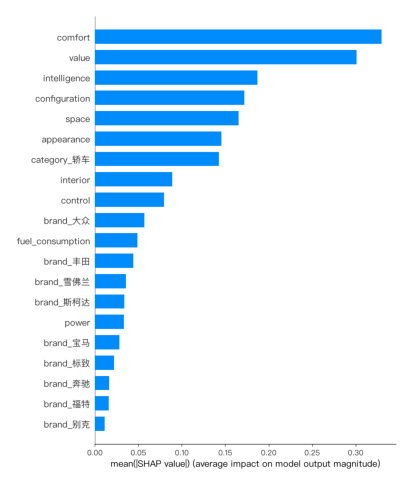

In [29]:
# Sales attribution: does sentiment improve forecasting? + SHAP aspect ranking.
print('=== Attribution: forecasting with vs without sentiment ===')
print(attr.round(4).to_string(index=False))
print('\n=== SHAP mean |SHAP| by aspect (higher = more important for sales) ===')
sr = shap_rank.rename(columns={'Unnamed: 0': 'aspect'}).sort_values('mean_abs_shap', ascending=False)
print(sr.round(4).to_string(index=False))

p = os.path.join(FIG, 'stage4_shap_bar.png')
if os.path.exists(p):
    img = plt.imread(p); fig, ax = plt.subplots(figsize=(11, 5))
    ax.imshow(img); ax.axis('off'); plt.tight_layout(); plt.show()

### 5.3 时序因果：过去舆情能否预测未来销量（Granger）

在品牌级（48 个有足够样本的品牌）检验各维度舆情对销量的 Granger 因果：

- 约 **10-15% 的品牌**在至少一个维度上显著（如空间维度 7/48 显著），说明舆情→销量的因果信号存在但较弱、滞后较长。
- 全市场聚合层面因果关系不显著——与汽车（高单价、长决策周期）舆情影响缓慢、被外部因素稀释的常态相符，结论需保守解读。

=== Brand-level significance rate by aspect (n brands tested) ===
          aspect  n_brands_tested  n_sig  sig_rate
           space               48      7    0.1458
        interior               48      6    0.1250
   configuration               48      6    0.1250
fuel_consumption               48      5    0.1042
           value               48      5    0.1042
      appearance               48      4    0.0833
           power               48      4    0.0833
    intelligence               48      4    0.0833
         control               48      2    0.0417
         comfort               48      2    0.0417

=== Market-level Granger p-values by aspect ===
          aspect  p_lag1  p_lag2  p_lag3  min_p  sig_any
         control  0.0730  0.0838  0.0784 0.0730    False
   configuration  0.1915  0.4673  0.6968 0.1915    False
fuel_consumption  0.8160  0.3308  0.4021 0.3308    False
         comfort  0.3313  0.4798  0.5450 0.3313    False
           space  0.7908  0.7341  0.540

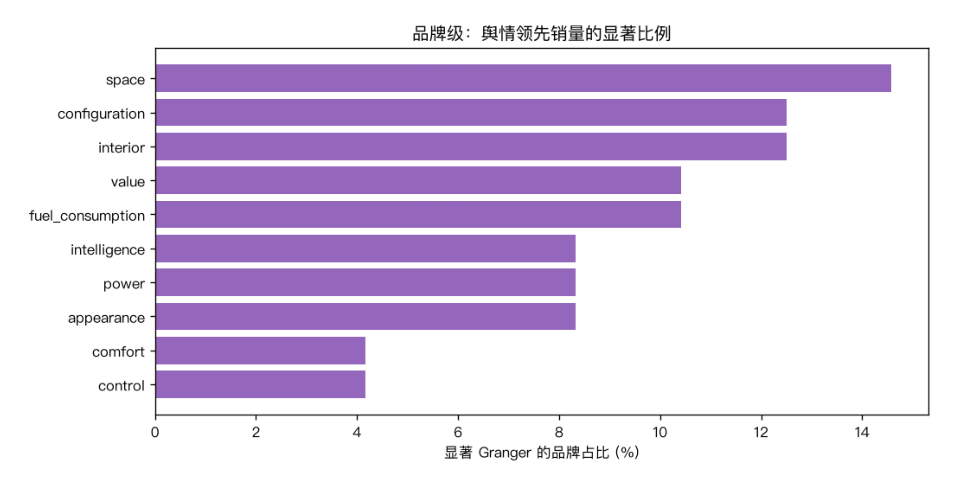

In [30]:
# Granger causality: does past sentiment predict future sales?
print('=== Brand-level significance rate by aspect (n brands tested) ===')
print(granger_brand.round(4).to_string(index=False))
print('\n=== Market-level Granger p-values by aspect ===')
print(granger_mkt.round(4).to_string(index=False))

p = os.path.join(FIG, 'stage4_granger_brand.png')
if os.path.exists(p):
    img = plt.imread(p); fig, ax = plt.subplots(figsize=(11, 5))
    ax.imshow(img); ax.axis('off'); plt.tight_layout(); plt.show()

### 5.4 全市场舆情与销量时序

下图为全市场层面各维度情感与总销量的月度走势叠加，直观展示二者长期关系。

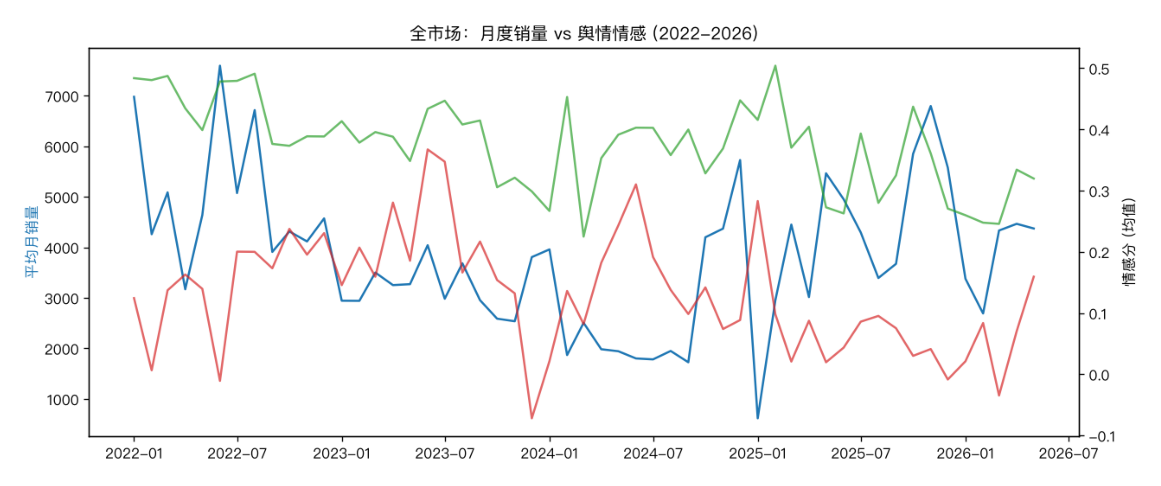

In [31]:
# Market-level sentiment vs sales over time.
p = os.path.join(FIG, 'stage4_market_timeseries.png')
if os.path.exists(p):
    img = plt.imread(p); fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(img); ax.axis('off'); plt.tight_layout(); plt.show()

### 5.5 阶段四产出汇总

| 产出 | 说明 | 文件 |
|------|------|------|
| ABSA 结果（全量） | 28,724 条评论 × 10 维度情感 | `data/sentiment/absa/absa_results.csv` |
| 情感-销量月序（车系） | 486 系月度情感与销量 | `data/processed/stage4/sentiment_monthly_by_series.csv` |
| 情感-销量月序（品牌） | 多品牌月度情感与销量 | `data/processed/stage4/sentiment_sales_monthly_brand.csv` |
| 归因指标 | 含/不含舆情对比 | `data/processed/stage4/attribution_metrics.csv` |
| SHAP 维度排名 | 各维度重要性 | `data/processed/stage4/aspect_shap_ranking.csv` |
| Granger 品牌级 | 显著性比率 | `data/processed/stage4/granger_brand_summary.csv` |
| Granger 市场级 | p 值 | `data/processed/stage4/granger_market.csv` |

In [32]:
# Stage 4 deliverables summary
stage4_files = {
    'ABSA results (full)': 'data/sentiment/absa/absa_results.csv',
    'Sentiment x sales monthly (series)': 'data/processed/stage4/sentiment_monthly_by_series.csv',
    'Sentiment x sales monthly (brand)': 'data/processed/stage4/sentiment_sales_monthly_brand.csv',
    'Attribution metrics': 'data/processed/stage4/attribution_metrics.csv',
    'SHAP aspect ranking': 'data/processed/stage4/aspect_shap_ranking.csv',
    'Granger brand summary': 'data/processed/stage4/granger_brand_summary.csv',
    'Granger market summary': 'data/processed/stage4/granger_market.csv',
}
print('Stage 4 deliverables:')
for k, v in stage4_files.items():
    print(f'  - {k}: {v}')
print('\nFigures: stage4_shap_bar.png, stage4_shap_summary.png, stage4_granger_brand.png,')
print('          stage4_granger_market.png, stage4_market_timeseries.png')

Stage 4 deliverables:
  - ABSA results (full): data/sentiment/absa/absa_results.csv
  - Sentiment x sales monthly (series): data/processed/stage4/sentiment_monthly_by_series.csv
  - Sentiment x sales monthly (brand): data/processed/stage4/sentiment_sales_monthly_brand.csv
  - Attribution metrics: data/processed/stage4/attribution_metrics.csv
  - SHAP aspect ranking: data/processed/stage4/aspect_shap_ranking.csv
  - Granger brand summary: data/processed/stage4/granger_brand_summary.csv
  - Granger market summary: data/processed/stage4/granger_market.csv

Figures: stage4_shap_bar.png, stage4_shap_summary.png, stage4_granger_brand.png,
          stage4_granger_market.png, stage4_market_timeseries.png


## 6. 结论与后续工作

**已完成**：
- 阶段一：数据准备（6 份数据集，采集 / 清洗 / 对齐 / 分析就绪表）
- 阶段二：筛选与探索性可视化（连续月份筛选、时序汇总、销量/分类/硬件可视化）
- 阶段三：销量预测建模（ARIMA / Prophet / Prophet+外生 / XGBoost / LSTM / 融合 + 分层抽样评估、滚动交叉验证、特征消融、预测区间）
- 阶段四：舆情深度分析与销量归因（深层 ABSA 全量 28,724 条、XGBoost+SHAP 销量归因、Granger 时序因果）

**核心结论**：
1. 销量预测：在 150 系分层抽样评估集上，融合 / XGBoost / LSTM 等机器学习方法相较逐车系 ARIMA 基线更稳健；节假日、促销季与价格等外生变量对月粒度销量预测贡献较小。
2. 舆情归因：把舆情特征加入车系级销量模型后，R² 由 −0.073 提升至 0.138、MAPE 由 16.5% 降至 14.7%；SHAP 显示舒适性、性价比、智能化是最影响销量的舆情维度。
3. 时序因果：品牌级约 10-15% 的品牌在至少一个舆情维度上呈 Granger 显著，全市场级不显著——说明舆情→销量的因果信号存在但弱、且滞后长，结论需保守。

**后续工作**：
1. 看板交付（Streamlit + ECharts 交互式可视化，独立交付物）
2. （可选）扩产：将舆情归因从 486 个有评论车系扩展到全部 669 个建模车系
3. 生产化：模型训练与部署自动化